Phase 1: Environment Setup & Library Ingestion
In this stage, we construct our computational environment. We import pandas and numpy for core matrix manipulations, matplotlib and seaborn for graphic plotting, and foundational utilities from scikit-learn to build, validate, and scale our regression architecture.

In [47]:
# ==========================================
# STEP 1: IMPORT LIBRARIES
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning & Evaluation Tools
from sklearn.model_selection import KFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# AI Models for Comparison
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor

# Settings
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')
print("Setup complete. Libraries imported successfully!")

Setup complete. Libraries imported successfully!


Phase 2: Data Resampling, Index Alignment, and Integration
Our target parameter (Groundwater Level) is captured daily, while our climate indicators are recorded monthly. To build a mathematically uniform dataframe, we apply temporal resampling (.resample('MS').mean()) to compute true monthly averages for groundwater. We then execute a strict database-style inner join matching on historical timestamps, completely removing incomplete entries to generate a pristine feature matrix.

In [48]:
# ==========================================
# STEP 2: DATA PREPARATION & UNIFORM DATAFRAME
# ==========================================

# 1. Load and process daily Groundwater Level (GWL) data
gwl = pd.read_excel("GWL_Data.xlsx")
gwl['Date'] = pd.to_datetime(gwl['Date'])
gwl.set_index('Date', inplace=True)

# Resample daily data to monthly averages
gwl_monthly = gwl.resample('MS').mean()
gwl_monthly.columns = ['GWL']

# 2. Load and process monthly Climate Data
climate_files = {
    'ETa': 'ETa_CibolaNC_TerraClimate.csv',
    'ETo': 'ETo_CibolaNC_TerraClimate.csv',
    'Pr': 'Pr_CibolaNC_TerraClimate.csv',
    'Sm': 'Sm_CibolaNC_TerraClimate.csv',
    'Ta_Max': 'Ta_Max_CibolaNC_TerraClimate.csv',
    'Ta_Min': 'Ta_Min_CibolaNC_TerraClimate.csv'
}

dataframes = []
for var_name, file_name in climate_files.items():
    df = pd.read_csv(file_name)
    df.columns = ['DateTime', var_name]
    df['DateTime'] = pd.to_datetime(df['DateTime'])
    df.set_index('DateTime', inplace=True)
    dataframes.append(df)

# Concatenate all climate variables side-by-side
climate_df = pd.concat(dataframes, axis=1)

# 3. Merge Climate and GWL data together into a uniform dataframe
df_final = climate_df.join(gwl_monthly, how='inner').dropna()

print(f"Uniform Dataframe Prepared! Shape: {df_final.shape}")
display(df_final.head())

Uniform Dataframe Prepared! Shape: (744, 7)


,ETa,ETo,Pr,Sm,Ta_Max,Ta_Min,GWL
1958-01-01,73.2,73.2,105,183.9,14.7,1.2,200.648070
1958-02-01,66.5,66.5,106,218.5,13.1,2.8,202.248189
1958-03-01,77.5,92.3,58,196.2,17.4,5.2,204.212952
1958-04-01,86.5,126.3,37,145.2,24.4,11.7,203.520853
1958-05-01,143.3,155.7,140,134.9,28.5,15.8,204.262900


Phase 3: Exploratory Data Analysis & Feature Interaction
Before running machine learning models, we must inspect our feature distributions and relationships. We generate histograms to observe skewness or outliers within individual parameters. Concurrently, we construct bivariate scatter plots mapping each climate variable directly against Groundwater Levels to discover underlying linear or non-linear trends.

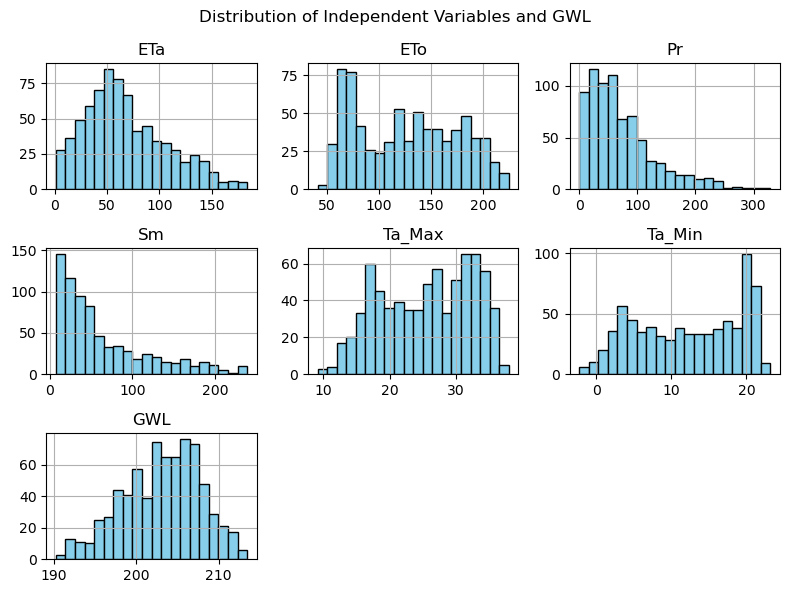

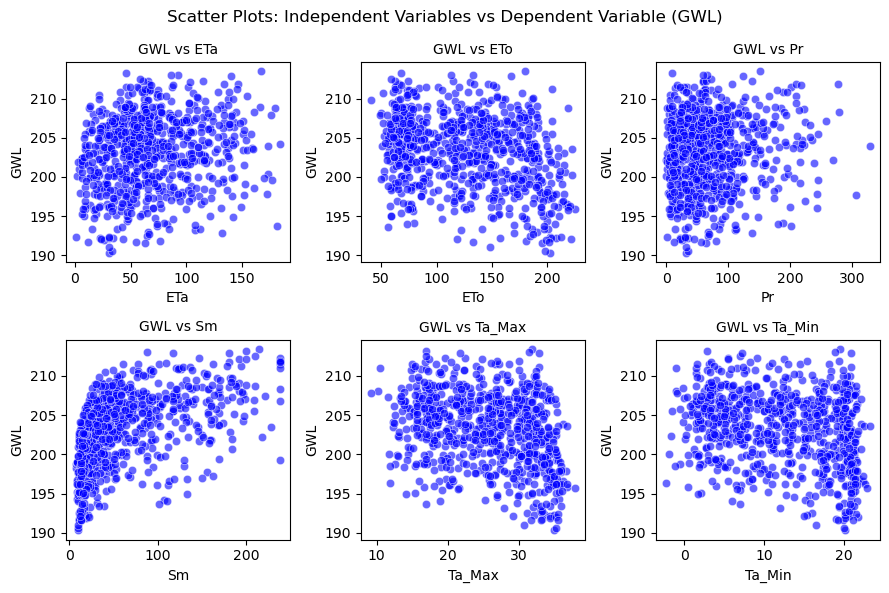

In [49]:
# ==========================================
# STEP 3: EXPLORATORY DATA ANALYSIS (EDA)
# ==========================================
features = ['ETa', 'ETo', 'Pr', 'Sm', 'Ta_Max', 'Ta_Min']

# 1. Generate Histograms
df_final.hist(bins=20, figsize=(8, 6), color='skyblue', edgecolor='black')
plt.suptitle('Distribution of Independent Variables and GWL', fontsize=12)
plt.tight_layout()
plt.show()

# 2. Generate Scatter Plots
fig, axes = plt.subplots(2, 3, figsize=(9, 6))
fig.suptitle('Scatter Plots: Independent Variables vs Dependent Variable (GWL)', fontsize=12)
axes = axes.flatten()

for i, feature in enumerate(features):
    sns.scatterplot(data=df_final, x=feature, y='GWL', ax=axes[i], alpha=0.6, color='blue')
    axes[i].set_title(f'GWL vs {feature}', fontsize=10)

plt.tight_layout()
plt.show()

Phase 4: Cross-Validated Model Evaluation & Leaderboard Synthesis
To accurately assess our AI models, we implement a 3-Fold Cross-Validation approach. This splits our data repeatedly into distinct training and testing blocks, ensuring every data point is independently validated.

For models sensitive to variance in scaling (like Support Vector Regressors), we utilize a Scikit-Learn Pipeline. This forces data scaling (StandardScaler) to happen exclusively inside each independent validation fold, structurally blocking data leakage and maintaining a strict, enterprise-grade validation protocol.

In [50]:
# ==========================================
# STEP 4: MODEL DEVELOPMENT & EVALUATION
# ==========================================

# Separate inputs (X) from target (y)
X = df_final[features]
y = df_final['GWL']

# Configure a reproducible 3-Fold Cross Validation
kf = KFold(n_splits=3, shuffle=True, random_state=42)

# Define our suite of AI models to benchmark
models = {
    "Gradient Boosting Regressor": GradientBoostingRegressor(random_state=42),
    "Random Forest Regressor": RandomForestRegressor(n_estimators=100, random_state=42),
    "Support Vector Regressor (SVR)": make_pipeline(StandardScaler(), SVR(kernel='rbf', C=100)),
    "Decision Tree Regressor": DecisionTreeRegressor(max_depth=5, random_state=42)
}

# Evaluate each model sequentially
results = []
for name, model in models.items():
    # Execute 3-fold cross-validation
    cv_scores = cross_validate(model, X, y, cv=kf, 
                               scoring={'r2': 'r2', 'rmse': 'neg_root_mean_squared_error'})
    
    # Calculate means from the scores array
    mean_r2 = cv_scores['test_r2'].mean()
    mean_rmse = -cv_scores['test_rmse'].mean()  # Correct the sign mapping from sklearn
    
    # Save statistics
    results.append({
        'Model Name': name, 
        'R2 Score (Variance Explained)': round(mean_r2, 4), 
        'RMSE (Prediction Error in m)': round(mean_rmse, 4)
    })

# ==========================================
# STEP 5: FINAL LEADERBOARD COMPARISON
# ==========================================
results_df = pd.DataFrame(results)

# Sort from best performance to worst based on R2 Score
results_df = results_df.sort_values(by='R2 Score (Variance Explained)', ascending=False).reset_index(drop=True)

print("\n=== FINAL MODEL PERFORMANCE COMPARISON ===")
display(results_df)


=== FINAL MODEL PERFORMANCE COMPARISON ===


,Model Name,R2 Score (Variance Explained),RMSE (Prediction Error in m)
0,Gradient Boosting Regressor,0.3983,3.6495
1,Random Forest Regressor,0.3796,3.7068
2,Support Vector Regressor (SVR),0.3726,3.7227
3,Decision Tree Regressor,0.2886,3.9649
